# Introduction
This Coursera Lab Jupyter notebook implements (1) an open-loop estimator for the spring-mass-damper system, and (2) a Kalman-filter for the same system that is poorly initialized.

Don't forget that to execute the Octave code in any cell, depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell. I refer to this as "< shift \> < enter \>" in my instructions below.

### Defining the constants and setting up the problem
The next notebook cell loads the state-space model and the dataset from simulating the model. Place the cursor inside the cell and depress < shift > < enter >. Do the same for the following cells to execute their contents.

In [1]:
% Load data from simulation of system dynamic model. These data were created by the code in 
% Lesson 1.4.2, and are the same data used in Lesson 1.4.3.
%
% Data file contains Ad Bd Cd Dd SigmaV SigmaW dT t u x z
load readonly/simOut.mat

### (1) Run an open-loop state estimator using the data loaded from "simOut.mat"
The next notebook cell runs an open-loop estimator that does not have the measurement feedback that is normally used in a Kalman filter.

In [2]:
[nx,nt] = size(x);
xhat = zeros(nx,1);          % Initialize state estimate at time zero
SigmaX = zeros(nx,nx);       %  and its covariance matrix
xhatOLstore = zeros(nx,nt);  % Reserve storage for all open-loop (OL) state
boundOLstore = zeros(nx,nt); %  estimates and their confidence bounds

for k = 2:nt                 % Execute the open-loop estimator
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % For open-loop state estimation, there is no measurement feedback.
  % So, delete steps 1c, 2a, 2b, and 2c.
  
  % [Store information for evaluation/plotting purposes]  
  xhatOLstore(:,k) = xhat; 
  boundOLstore(:,k) = 3*sqrt(diag(SigmaX));
end  

### Plot simulation outputs from open-loop state estimator
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

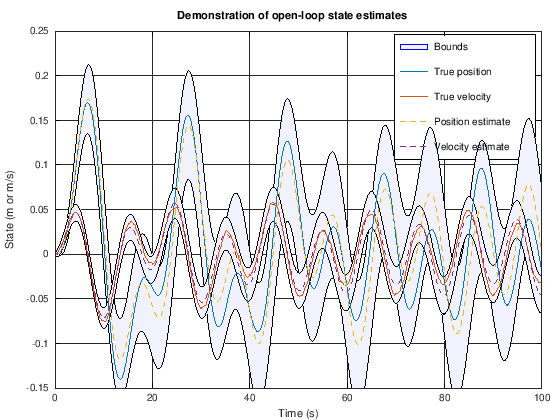

In [3]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatOLstore-boundOLstore fliplr(xhatOLstore+boundOLstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 
h2 = plot(t,x',t,xhatOLstore','--'); ylim([-0.15 0.25]);
legend([h2;h1a],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('Demonstration of open-loop state estimates    '); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

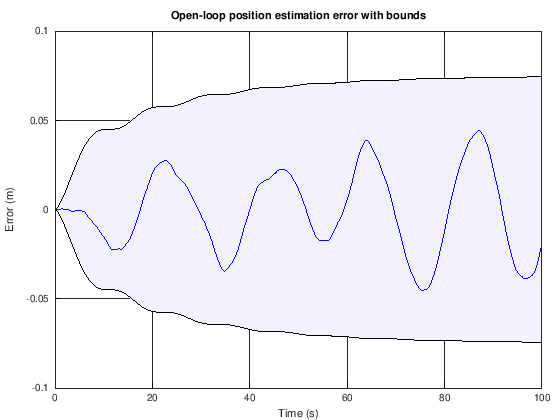

In [4]:
xerr = x - xhatOLstore; 
fill([t fliplr(t)],[-boundOLstore(1,:) fliplr(boundOLstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Open-loop position estimation error with bounds'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

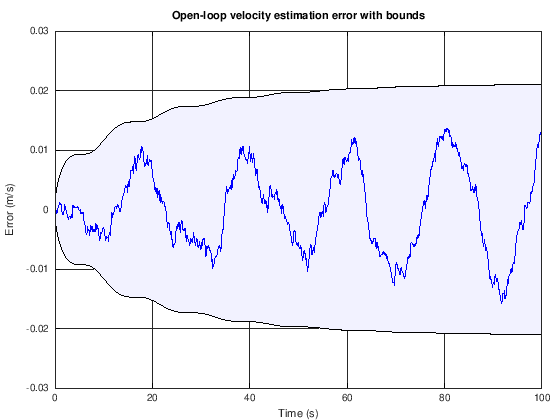

In [5]:
fill([t fliplr(t)],[-boundOLstore(2,:) fliplr(boundOLstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
title('Open-loop velocity estimation error with bounds'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

### (2) Run a Kalman filter using the data loaded from "simOut.mat" but with bad initialization
The next notebook cell runs a Kalman-filter state estimator that is poorly initialized.

In [6]:
xhatBIstore = zeros(nx,nt);  % Reserve storage for all KF state estimates and their
boundBIstore = zeros(nx,nt); %  confidence bounds for the bad-init (BI) case

xhat = [0.25; -0.05];        % Initialize state estimate at time zero
SigmaX = diag(xhat/2).^2;    % Initialize state covariance matrix at time zero
                             % assuming that xhat is a 2-sigma measurement
                             
xhatBIstore(:,1) = xhat;     % Store in data structure
boundBIstore(:,1)=3*sqrt(diag(SigmaX));

for k = 2:nt
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*Cd)*SigmaX;
 
  % [Store information for evaluation/plotting purposes]  
  xhatBIstore(:,k) = xhat; 
  boundBIstore(:,k) = 3*sqrt(diag(SigmaX));
end

### Plot simulation outputs from Kalman-filter state estimator (with bad initialization)
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

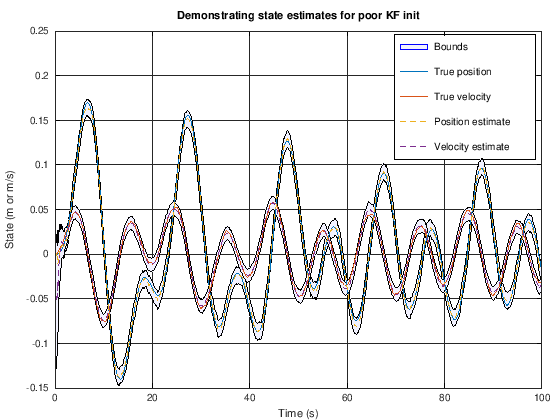

In [7]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatBIstore-boundBIstore fliplr(xhatBIstore+boundBIstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 
h2 = plot(t,x',t,xhatBIstore','--'); ylim([-0.15 0.25]);
legend([h2;h1a],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('Demonstrating state estimates for poor KF init'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

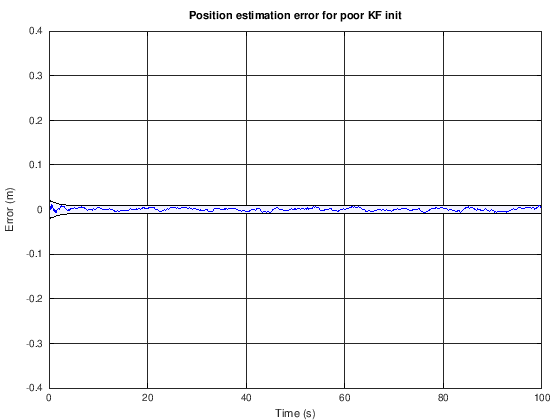

In [8]:
xerr = x - xhatBIstore; 
fill([t fliplr(t)],[-boundBIstore(1,:) fliplr(boundBIstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error for poor KF init'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

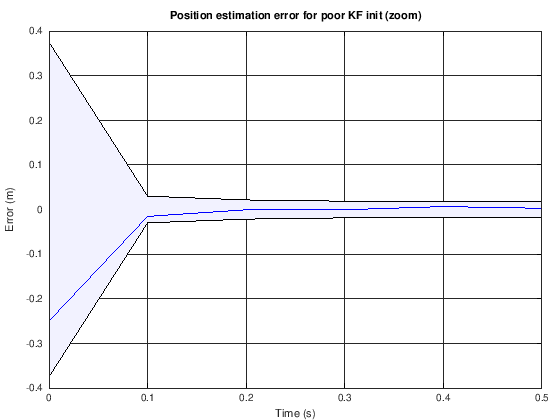

In [9]:
fill([t fliplr(t)],[-boundBIstore(1,:) fliplr(boundBIstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error for poor KF init (zoom)'); 
xlabel('Time (s)'); ylabel('Error (m)'); 
xlim([0 0.5]); % zoom

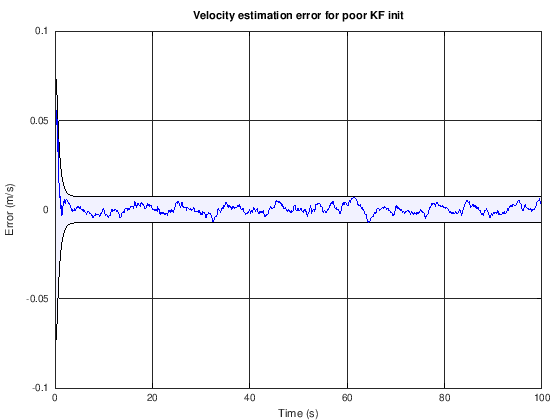

In [10]:
fill([t fliplr(t)],[-boundBIstore(2,:) fliplr(boundBIstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
title('Velocity estimation error for poor KF init'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

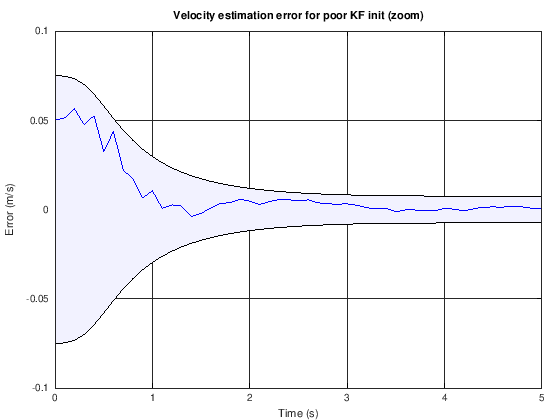

In [11]:
fill([t fliplr(t)],[-boundBIstore(2,:) fliplr(boundBIstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
title('Velocity estimation error for poor KF init (zoom)'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 
xlim([0 5]); % zoom

### User workspace
You can enter your own Octave commands into the next cell to query variables, plot results, or anything you like.